In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import xml.etree.ElementTree as ET
import os

HOME = os.path.abspath(os.sep)
dataset_folder = os.getcwd() + "/Dataset/Images"

In [2]:
import json
from torch.utils.data import Dataset

class GunDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, transform=None):
      with open(annotation_dir, "r") as f:
        coco_data = json.load(f)
      self.image_dir = image_dir
      self.transform = transform
      self.images = coco_data['images']
      self.annotations = coco_data['annotations']
      self.classes = {"gun": 0}
      self.img_to_anns = {img['id']: [] for img in self.images}
      for ann in self.annotations:
          self.img_to_anns[ann['image_id']].append(ann)
      
    def __len__(self):
        return len(self.images)
      
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, str(self.images[idx]['file_name']))
        image = Image.open(image_path).convert("RGB")
        
        # Ottieni le annotazioni per questa immagine
        img_id = self.images[idx]['id']
        annotations = self.img_to_anns[img_id]
        
        # Prepara boxes e labels per tutte le annotazioni di questa immagine
        boxes = []
        labels = []
        
        for ann in annotations:
            # Le box COCO sono in formato [x, y, width, height]
            # Convertiamo in [x1, y1, x2, y2]
            box = ann['bbox']
            x, y, w, h = box
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])
        
        # Converti in tensori
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Applica le trasformazioni all'immagine
        if self.transform is not None:
            image = self.transform(image)
            
        return image, boxes, labels
        

In [3]:
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split

transform = T.Compose([T.ToTensor()])

train_dataset, val_dataset = random_split(GunDataset(dataset_folder, dataset_folder+"/_annotations.coco.json", transform=transform), [0.8, 0.2])

num_workers = 2
if os.name == 'nt':
    num_workers = 0
    
def collate_fn(batch):
    return tuple(zip(*batch))

# Modifica i DataLoader per usare la funzione di collate personalizzata
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True, 
    num_workers=num_workers,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False, 
    num_workers=num_workers,
    collate_fn=collate_fn
)

In [4]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

in_features = model.roi_heads.box_predictor.cls_score.in_features

# Rimpiazziamo il classificatore con uno nuovo per il gun detection
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [5]:
from torchmetrics.detection import MeanAveragePrecision
import time

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    
    # Inizializza metric calculator
    metric = MeanAveragePrecision()
    
    print(f"Epoch: {epoch+1}")
    start_time = time.time()
    
    for i, (images, targets_boxes, targets_labels) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        targets = []
        
        # Formatta i target come richiesto da Faster R-CNN
        for boxes, labels in zip(targets_boxes, targets_labels):
            target = {}
            target['boxes'] = boxes.to(device)
            target['labels'] = labels.to(device)
            targets.append(target)
        
        # Forward pass e calcolo loss
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        
        # Ottieni le predizioni
        model.eval()
        with torch.no_grad():
            predictions = model(images)
        model.train()
        
        # Aggiorna le metriche
        metric.update(predictions, targets)
        
        if i % 50 == 0:  # Log ogni 50 batch
            print(f"Batch [{i}/{len(data_loader)}], Loss: {losses.item():.4f}")
    
    # Calcola le metriche finali
    metric_results = metric.compute()
    
    # Estrai le metriche principali
    metrics = {
        'loss': total_loss / len(data_loader),
        'mAP': metric_results['map'].item(),
        'mAP_50': metric_results['map_50'].item(),  # mAP at IoU=0.50
        'mAP_75': metric_results['map_75'].item(),  # mAP at IoU=0.75
        'mAR_1': metric_results['mar_1'].item(),    # mean Average Recall for max 1 detection
        'mAR_10': metric_results['mar_10'].item(),  # mean Average Recall for max 10 detections
    }
    
    print(f"\nEpoch {epoch+1} results:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    
    return metrics

def validate(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision()
    
    with torch.no_grad():
        for images, targets_boxes, targets_labels in data_loader:
            images = list(image.to(device) for image in images)
            targets = []
            
            for boxes, labels in zip(targets_boxes, targets_labels):
                target = {}
                target['boxes'] = boxes.to(device)
                target['labels'] = labels.to(device)
                targets.append(target)
            
            predictions = model(images)
            metric.update(predictions, targets)
    
    metric_results = metric.compute()
    
    metrics = {
        'val_mAP': metric_results['map'].item(),
        'val_mAP_50': metric_results['map_50'].item(),
        'val_mAP_75': metric_results['map_75'].item(),
        'val_mAR_1': metric_results['mar_1'].item(),
        'val_mAR_10': metric_results['mar_10'].item(),
    }
    
    print("\nValidation results:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    return metrics

# Funzione principale di training
def train_model(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=10):
    best_map = 0
    history = []
    
    for epoch in range(num_epochs):
        # Training
        train_metrics = train_one_epoch(model, optimizer, train_loader, device, epoch)
        
        # Validation
        val_metrics = validate(model, val_loader, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_metrics['val_mAP'] > best_map:
            best_map = val_metrics['val_mAP']
            torch.save(model.state_dict(), 'best_model.pth')
        
        # Combine metrics and save history
        epoch_metrics = {**train_metrics, **val_metrics}
        history.append(epoch_metrics)
        
    return history

In [6]:
def plot_metrics(history):
    metrics = ['mAP', 'val_mAP']  # Le metriche che vogliamo visualizzare
    plt.figure(figsize=(10, 6))
    
    for metric in metrics:
        values = [x[metric] for x in history]
        plt.plot(values, label=metric)
    
    plt.title('Training Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch: 1
Batch [0/149], Loss: 0.7708
Batch [50/149], Loss: 0.1486
Batch [100/149], Loss: 0.1458

Epoch 1 results:
loss: 0.1629
mAP: 0.4525
mAP_50: 0.7273
mAP_75: 0.4802
mAR_1: 0.4457
mAR_10: 0.5744
Time taken: 700.06 seconds

Validation results:
val_mAP: 0.5781
val_mAP_50: 0.8481
val_mAP_75: 0.6367
val_mAR_1: 0.5161
val_mAR_10: 0.6600
Epoch: 2
Batch [0/149], Loss: 0.1204
Batch [50/149], Loss: 0.1060
Batch [100/149], Loss: 0.0709

Epoch 2 results:
loss: 0.0997
mAP: 0.6462
mAP_50: 0.9242
mAP_75: 0.7213
mAR_1: 0.5945
mAR_10: 0.7123
Time taken: 647.56 seconds

Validation results:
val_mAP: 0.6031
val_mAP_50: 0.8884
val_mAP_75: 0.6627
val_mAR_1: 0.5380
val_mAR_10: 0.6666
Epoch: 3
Batch [0/149], Loss: 0.1209
Batch [50/149], Loss: 0.0679
Batch [100/149], Loss: 0.0654

Epoch 3 results:
loss: 0.0837
mAP: 0.7121
mAP_50: 0.9582
mAP_75: 0.8093
mAR_1: 0.6524
mAR_10: 0.7608
Time taken: 1122.13 seconds

Validation results:
val_mAP: 0.6335
val_mAP_50: 0.8876
val_mAP_75: 0.6939
val_mAR_1: 0.5716
val_mAR

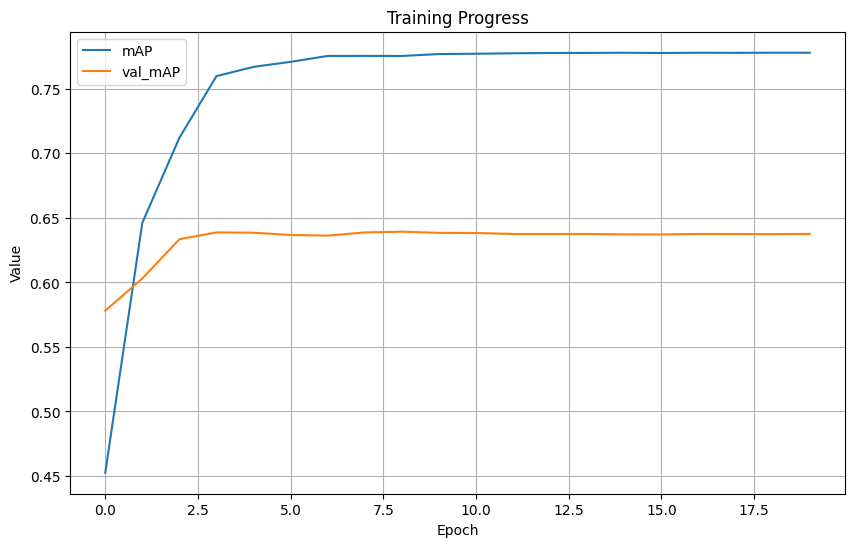

In [7]:
num_epochs = 20
history = train_model(model, optimizer, lr_scheduler, train_loader, val_loader, device, num_epochs)
plot_metrics(history)